In [1]:
file_path_criteria = "criteria.csv"
sim_runs = 10000
sampling_bins = 100

from aux import load_alternatives, load_criteria
from pivotal_bwt import bwt
from up_mavt import mc_simulation
from aggregation_methods import weighted_sum, geometric_mean, harmonic_mean, minimum, maximum

import numpy as np

file_path_elicitations = ["wbt_results.csv", "wbt_results.csv"]
err_list = []
num_criteria = sum(len(group_data['criteria']) for group_data in load_criteria(file_path_criteria, file_path_elicitations[0]).values())

# Assemble vf_list for mc_simulation
vf_list = [[] for _ in range(num_criteria)]
for fp in file_path_elicitations:
    dict_data = load_criteria(file_path_criteria, fp)
    results = bwt(dict_data)
    err_list.append(results["z"])
    for idx, crit_data in enumerate(
        crit_data for group_data in dict_data.values() for crit_data in group_data['criteria'].values()
    ):
        vf_list[idx].append((crit_data['value_function']))

print("Previous z values:", err_list)
print("Value Functions List:", vf_list)


Starting optimization...
Starting optimization...
Previous z values: [np.float64(4.715549534481889e-16), np.float64(4.715549534481889e-16)]
Value Functions List: [[<function <lambda> at 0x7f7a9e4e8c20>, <function <lambda> at 0x7f7a9e4e9260>], [<function <lambda> at 0x7f7a9e4e89a0>, <function <lambda> at 0x7f7a9e4e8f40>], [<function <lambda> at 0x7f7a9e4e8d60>, <function <lambda> at 0x7f7a9e4e9300>], [<function <lambda> at 0x7f7a9e4e8ae0>, <function <lambda> at 0x7f7a9e4e91c0>], [<function <lambda> at 0x7f7a9e4e85e0>, <function <lambda> at 0x7f7a9e4e8fe0>], [<function <lambda> at 0x7f7a9e4e8e00>, <function <lambda> at 0x7f7a9e4e93a0>]]


In [31]:

# Load alternatives
alternatives = load_alternatives("alternatives.csv")
display(alternatives)
print(len(alternatives))


[{'Salary': {'Normal': [1500, 100]},
  'Paid Leave': {'Uniform': [4, 8]},
  'Bonus': {'Discrete': [[2000, 2500, 3000]]},
  'Remote Work Days': {'Triangular': [2, 3, 4]},
  'Training Budget': {'Normal': [1000, 200]},
  'Commute Time': {'Uniform': [30, 90]}},
 {'Salary': {'Normal': [1800, 150]},
  'Paid Leave': {'Uniform': [6, 10]},
  'Bonus': {'Discrete': [[3000, 4000, 5000]]},
  'Remote Work Days': {'Triangular': [3, 4, 5]},
  'Training Budget': {'Normal': [1500, 300]},
  'Commute Time': {'Uniform': [20, 40]}},
 {'Salary': {'Normal': [1300, 200]},
  'Paid Leave': {'Uniform': [2, 6]},
  'Bonus': {'Discrete': [[1000, 1500, 2000]]},
  'Remote Work Days': {'Triangular': [1, 2, 3]},
  'Training Budget': {'Normal': [500, 100]},
  'Commute Time': {'Uniform': [60, 120]}}]

3


In [16]:
from weight_sampling import run_mcmc_sampling
num_groups = len(load_criteria(file_path_criteria, file_path_elicitations[0]).keys())
first_run_error = err_list[0]
run_mcmc_sampling(dict_data, num_criteria, num_groups, first_run_error)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_crit, w_group, Z]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 20 seconds.
There were 7958 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [22]:
# count how many in posterior_samples.csv have z < first_run_error
with open("posterior_samples.csv", "r") as f:
    lines = f.readlines()
    count_better = sum(1 for line in lines[1:] if float(line.strip().split(",")[-1]) < first_run_error)
    total_samples = len(lines) - 1
    print(f"Number of samples with z < {first_run_error}: {count_better} out of {total_samples}")
# count how many in posterior_samples.csv have sum of criteria weights == 1
with open("posterior_samples.csv", "r") as f:
    lines = f.readlines()
    count_sum_one = sum(1 for line in lines[1:] if abs(sum(float(w) for w in line.strip().split(",")[:num_criteria]) - 1) < 1e-6)
    total_samples = len(lines) - 1
    print(f"Number of samples with sum of weights == 1: {count_sum_one} out of {total_samples}")

# apply constraints to each row in posterior_samples.csv and count how many satisfy them
with open("posterior_samples.csv", "r") as f:
    lines = f.readlines()
    count_constraints = 0
    for line in lines[1:]:
        weights = [float(w) for w in line.strip().split(",")[:num_criteria]]
        # Example constraints: weight[0] >= weight[1], weight[2] + weight[3] <= 0.5
        if weights[0] >= weights[1] and (weights[2] + weights[3] <= 0.5):
            count_constraints += 1
    total_samples = len(lines) - 1
    print(f"Number of samples satisfying constraints: {count_constraints} out of {total_samples}")

# Select only those that satisfy all these three conditions and delete the others
with open("posterior_samples.csv", "r") as f:
    lines = f.readlines()
    valid_lines = []
    for line in lines[1:]:
        weights = [float(w) for w in line.strip().split(",")[:num_criteria]]
        z_value = float(line.strip().split(",")[-1])
        if (abs(sum(weights) - 1) < 1e-6 and
            z_value < first_run_error and
            weights[0] >= weights[1] and
            (weights[2] + weights[3] <= 0.5)):
            valid_lines.append(line)
with open("posterior_samples_filtered.csv", "w") as f:
    f.write(lines[0])  # write header
    f.writelines(valid_lines)

Number of samples with z < 4.715549534481889e-16: 8000 out of 8000
Number of samples with sum of weights == 1: 8000 out of 8000
Number of samples satisfying constraints: 2858 out of 8000


In [ ]:

# Montecarlo
args = (alternatives, vf_list, err_list, weighted_sum, sim_runs, sampling_bins)
results, rel_errs = mc_simulation(*args, strict=True, weight_fixed=10)


In [27]:
display(len(results[0][0]))

3

In [ ]:
num_weight_sets = len(results)
num_alternatives = results[0].shape[1]

# per-set and overall accumulators
ranking_probs_per_set = np.zeros((num_alternatives, num_alternatives, num_weight_sets))
overall_ranking_probs = np.zeros((num_alternatives, num_alternatives))

for set_idx, set_results in enumerate(results):
    # Compute ranks so 1 = best (highest score)
    ranks = np.argsort(np.argsort(-set_results, axis=1), axis=1) + 1  # shape: (sim_runs, num_alternatives)

    for alt_idx in range(num_alternatives):
        for rank in range(1, num_alternatives + 1):
            p = np.mean(ranks[:, alt_idx] == rank)
            ranking_probs_per_set[alt_idx, rank-1, set_idx] = p
            overall_ranking_probs[alt_idx, rank-1] += p  # accumulate across weight sets

# Average over weight sets to get overall probabilities
overall_ranking_probs /= num_weight_sets


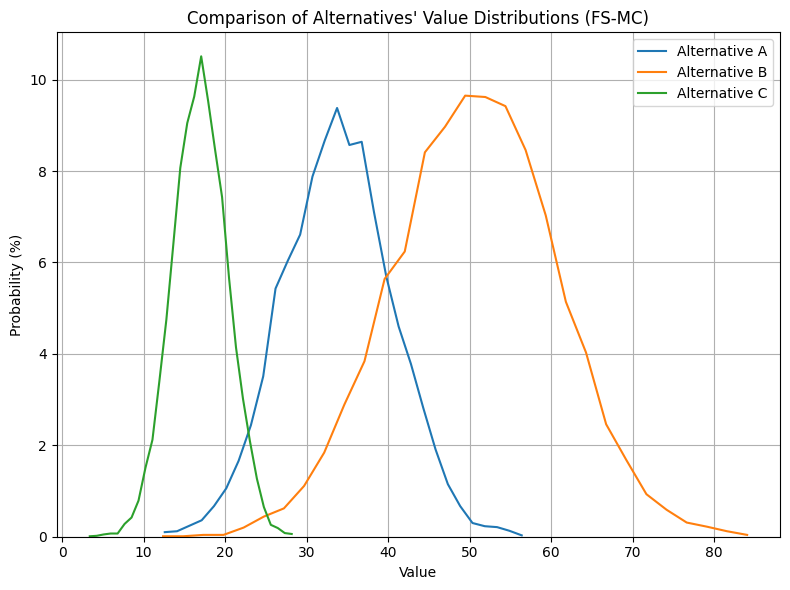

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot to compare alternatives' distributions in one figure
fig, ax = plt.subplots(figsize=(8, 6))
for alt_idx in range(len(alternatives)):
    
    data = results[0][:, alt_idx]

    hist, bin_edges = np.histogram(data, bins=30)
    hist_prob = hist / sim_runs  # probability per bin (sums to 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.plot(bin_centers, hist_prob * 100, label=f'Alternative {chr(65 + alt_idx)}')
ax.set_xlabel("Value")
ax.set_ylabel("Probability (%)")
ax.set_title("Comparison of Alternatives' Value Distributions (FS-MC)")
ax.legend()
plt.ylim(0)
plt.tight_layout()
plt.grid(True)
plt.show()

In [ ]:

# User's code with blue color scheme and improved aesthetics
data_pct = overall_ranking_probs * 100
annot = np.char.add(data_pct.round(1).astype(str), '%')

plt.figure(figsize=(10, 6))
cmap = sns.color_palette("Blues", as_cmap=True)  # Blue color scheme

sns.heatmap(
    data_pct.T,  # Transpose to show ranks as columns
    annot=annot.T,
    xticklabels=[f"A{alt+1}" for alt in range(num_alternatives)],
    yticklabels=[f"Rank {r+1}" for r in range(num_alternatives)],
    cmap=cmap,
    vmin=0, vmax=100,
    fmt="",
    square=True,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Probability (%)'}
)

plt.title("Overall Ranking Probabilities (%)", pad=20)
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label cutoff
plt.show()